
## Q2. Imagine two factories produce lightbulbs.

- Factory X makes 60% of the bulbs, and 2% of its bulbs are defective.
- Factory Y makes 40% of the bulbs, and 1% of its bulbs are defective.

What is the probability that a randomly purchased bulb is defective (P(Defective))?

- B₁ = bulb from Factory X, P(B₁) = 0.6
- B₂ = bulb from Factory Y, P(B₂) = 0.4
- P(Defective|B₁) = 0.02
- P(Defective|B₂) = 0.01

P(Defective) = P(Defective|B₁)P(B₁) + P(Defective|B₂)P(B₂)

P(Defective) = (0.02 * 0.6) + (0.01 * 0.4) = 0.012 + 0.004 = 0.016

So, 1.6% of all bulbs are defective.

In [1]:
# Given probabilities
P_B1 = 0.6
P_B2 = 0.4
P_defective_given_B1 = 0.02
P_defective_given_B2 = 0.01
# Law of Total Probability
P_defective = P_defective_given_B1*P_B1 + P_defective_given_B2*P_B2 
print("Probability that a randomly chosen bulb is defective :",P_defective)
print("In percentage :",P_defective*100,"%")

Probability that a randomly chosen bulb is defective : 0.016
In percentage : 1.6 %


# Baye's Theorem

## Spam Email - Free Probability

In [2]:
p_spam = 0.01 # probability of the email not being a spam 
p_free_given_spam = 0.9 # probability of email having the word free given that the email is spam - P(Free | Spam) 
p_free_given_not_spam = 0.05 # p of email having the word free given that the email is not spam

# first step calculate the total probability of email containing the word free
p_free = (p_free_given_spam * p_spam) + (p_free_given_not_spam * (1 - p_spam))
# for total what we do is : 1% spam emails * 90% has free + 99% non spam emails(1-spam) * 5% has free = total emails which has the word free

# now find P(Spam | Free), probabilty of email being a spam given that it has the word free
# this is what ML models really calculate
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

#display 
p_spam_given_free

0.15384615384615385

## Disease - Tested Positive Probability

In [3]:
p_disease = 0.02
p_test_positive_given_disease = 0.95
p_test_positive_given_no_disease = 0.1

p_test_positive = (p_disease * p_test_positive_given_disease) + ((1-p_disease) * p_test_positive_given_no_disease)

p_disease_given_test_positive = (p_test_positive_given_disease * p_disease) / p_test_positive

p_disease_given_test_positive

0.16239316239316237

# Probability Distributions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Bernaulli Distributions

Binary Distribution models a situation in exactly two outcomes : Success (1) or Failure (0)

Use Bernoulli when all of these are true:
- One trial
- Two outcomes
- Binary target

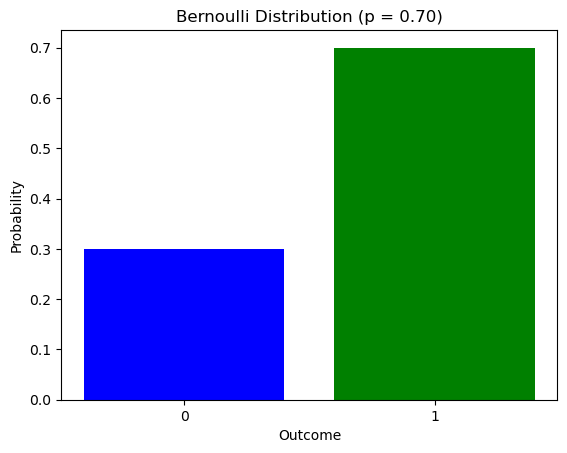

In [3]:
# Probability of success p for the Bernoulli distribution
p = 0.7

# Probabilities for the two outcomes
probabilities = [1 - p, p]

# Labels for the outcomes (0 and 1)
outcomes = ['0', '1']

# Plot the bar chart
plt.bar(outcomes, probabilities, color=['blue', 'green'])
plt.xlabel('Outcome')
plt.ylabel('Probability')
plt.title('Bernoulli Distribution (p = {:.2f})'.format(p))
plt.show()

## Binomial Distribution

if you see a peak in the histogram at a certain number, that means that number of successes is the most likely outcome. And if the histogram is spread out, that means there’s more variety in possible outcomes.

the histogram gives you a clear picture of how likely each number of successes is. For instance, if the probability of success is 0.5, the histogram will often be symmetrical, and the most likely outcome will be around the middle number of successes. If the probability of success is lower or higher, the histogram will show a peak toward the lower or higher number of successes, respectively.

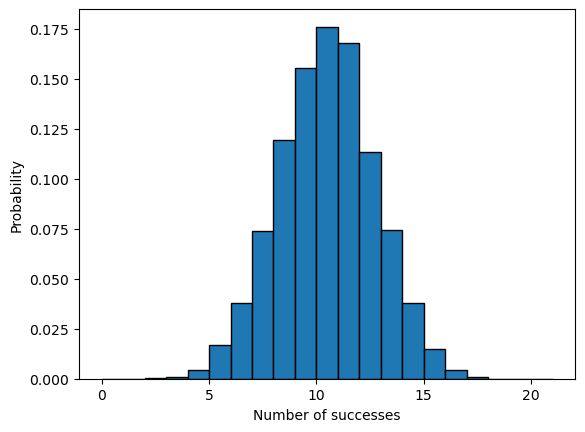

In [5]:
n = 20
p = 0.5
samples = np.random.binomial(n, p, size=10000)

plt.hist(samples, bins=range(n+2), density=True, edgecolor="black")
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.show()

- Without density=True, the y-axis shows counts (how many times each value occurred).

With density=True, the y-axis shows probability density — meaning:
- Each bar height represents the relative likelihood of that outcome.
- The sum of all bar areas ≈ 1 (like a proper probability distribution).

20 thavna coin toss cheytha 10 thavna heads(success) kittan saadhyatha ind nn aan ee graph paryne. ithil namma 20 trials vekknind athil 
oro trial lm event(getting heads) kittunnathinte distribution aan ith. aa size kond udheshchth veronnalla athrem thavna(10000) namma ee saanm 
repeat cheyym oru dataset indaakkna pola, athaayth 10000 experiment each having 20 trials and the event still being getting heads. nnitt athil 
oronnilm (oro experiment athaayth oro 20 trials lm) ethra thavna aan success (event sheryaavnth) ath edth plot cheyth appo x-axis l ethra thavna 
event sheryaay athaayth success kittiinum, y-axis l athin nthorm saadhyatha athaayth probability indennm aan kodthekkne. 

## Poisson Distribution

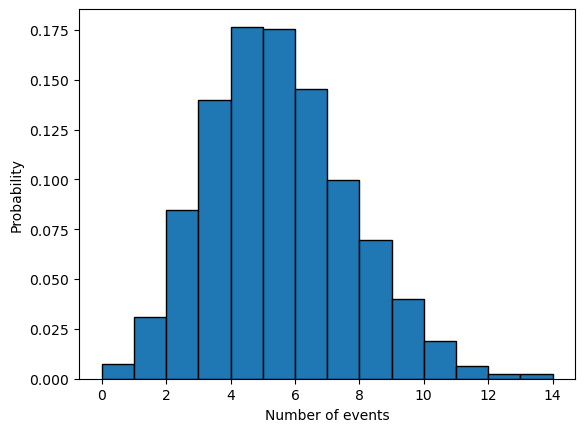

In [12]:
lam = 5  # average events per interval
data = np.random.poisson(lam, size=10000)

plt.hist(data, bins=range(15), density=True,edgecolor="black")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.show()

here we already assume the interval is defined like for example : lam = 5 emails per minute, 1 minute is the interval here, so what the graph gives 
us is that how many events (emails we get) happen over a fixed interval of time (during a minute) 

and here in the graph, k in the equation is represented by the x axis here.

## Geometric Distribution

The geometric distribution is focused on the number of trials needed to get the first success. For example, in a coin flip scenario, it would show the probability of getting your first head on the 3rd, 4th, or some other trial.

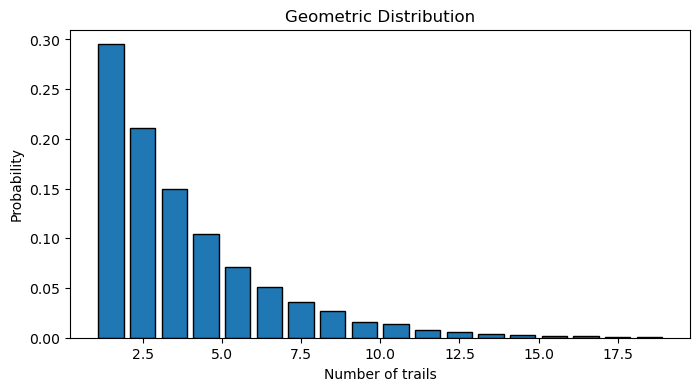

In [13]:
# "How many trials until I get a success?"
p = 0.3
geo_data = np.random.geometric(p, size=10000)

plt.figure(figsize=(8, 4))
plt.hist(geo_data, bins=np.arange(1, 20), density=True, rwidth=0.8, edgecolor='black')
plt.title('Geometric Distribution')
plt.xlabel("Number of trails")
plt.ylabel("Probability")
plt.show()

## Hypergeometric Distribution

This applies to sampling without replacement. Using the marble example in the graph, with 50 total marbles and 15 red, it shows the probability of drawing a certain number of red marbles in a sample of 10, highlighting the most probable outcomes.

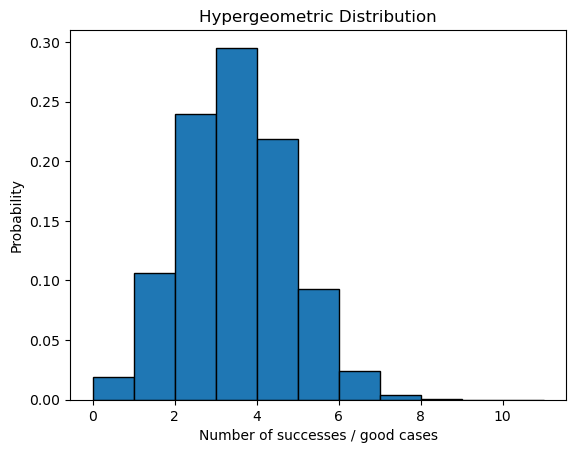

In [15]:
# ngood = successes in population, nbad = failures in population, nsample = number of draws
ngood, nbad, nsample = 15, 35, 10
hg_data = np.random.hypergeometric(ngood, nbad, nsample, size=10000)

#plt.figure(figsize=(8, 4))
plt.hist(hg_data, bins=np.arange(0, 12), density=True, edgecolor='black')
plt.title('Hypergeometric Distribution')
plt.ylabel("Probability")
plt.xlabel("Number of successes / good cases")
plt.show()

## Negative Binomial Distribution

This is for when you want to know how many trials it takes to reach a specific number of successes. In the context of the graph, like the coin flip example, it illustrates the probability of needing different number of flips to get 3 heads, helping you see the most probable outcome.

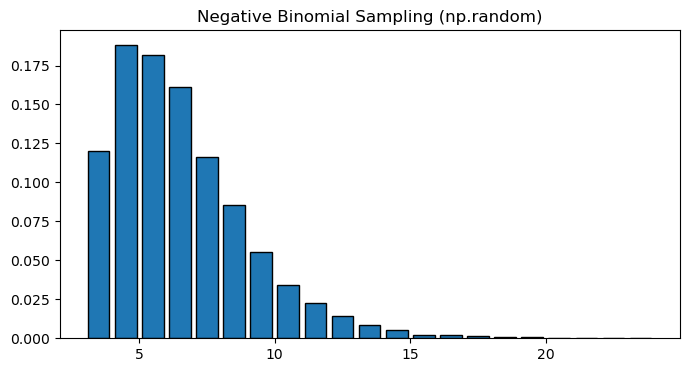

In [18]:
# NOTE: NumPy's version counts only FAILURES until n successes. 
# To get TOTAL trials, we add n to the result.
n_successes = 3
p_success = 0.5
nb_data = np.random.negative_binomial(n_successes, p_success, size=10000) + n_successes

plt.figure(figsize=(8, 4))
plt.hist(nb_data, bins=np.arange(3, 25), density=True, rwidth=0.8, edgecolor='black')
plt.title('Negative Binomial Sampling (np.random)')
plt.show()

## Uniform Discrete Distribution

This is when each possible outcome has the same probability. For instance, rolling a fair die – there's a 1 in 6 chance of getting any number from 1 to 6.

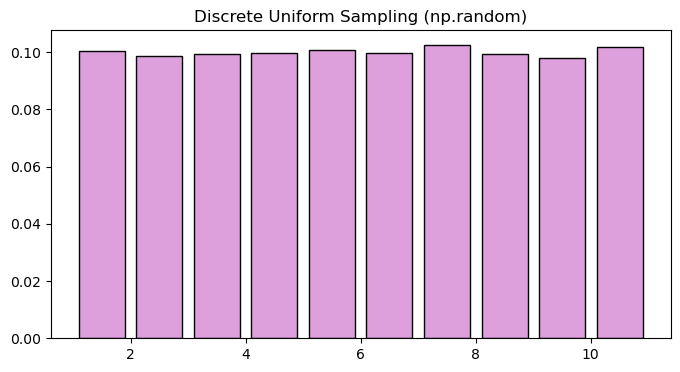

In [101]:
low, high = 1, 11 # high is exclusive in NumPy
u_data = np.random.uniform(low, high, size=10000) # as size increases it looks more like a discrete uniform graph as when the size is low we see small fluctuations 
# as irregularity in graph

plt.figure(figsize=(8, 4))
plt.hist(u_data, bins=np.arange(1, 12), density=True, rwidth=0.8, color='plum', edgecolor='black')
plt.title('Discrete Uniform Sampling (np.random)')
plt.show()

# Continuous Distributions

## Uniform Distribution

as number of samples increases it becomes comepletely flat

The red line is the true PDF

The histogram approaches it as data → ∞

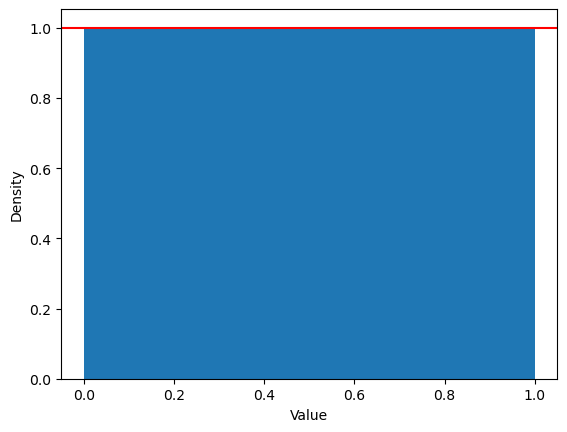

In [5]:
data = np.random.uniform(0, 1, size=2000000)
plt.axhline(1, color='red') 
plt.hist(data, bins=10, density=True)
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## Normal (Gaussian) Distribution

- Bell Curve Shaped 
- Mean = Median = Mode
- Symmetric
- loc - mean
- scale - how wide

density - probability density it shows how likely the value is to fall in that corresponding bin or range

value - features

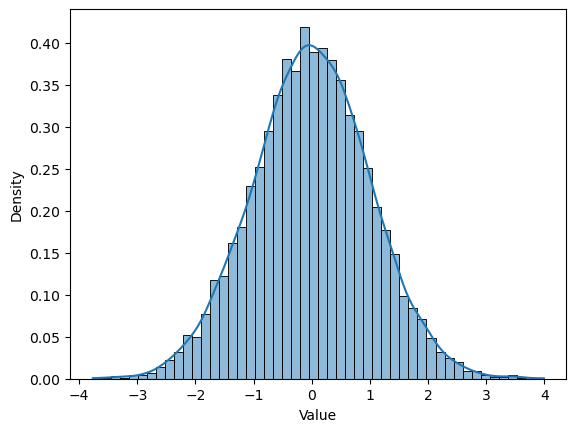

-0.002870584479952477 1.0058136074850677


In [6]:
data = np.random.normal(loc=0, scale=1, size=10000)

sns.histplot(data, kde=True, bins=50, stat="density")

plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

print(np.mean(data), np.std(data))

## Exponential Distribution

you can just think of the exponential distribution as a way to show how likely something is to happen as time goes by—like how long you'll wait before a machine part fails. The graph just shows that as time increases, the probability of it still working gradually drops off.

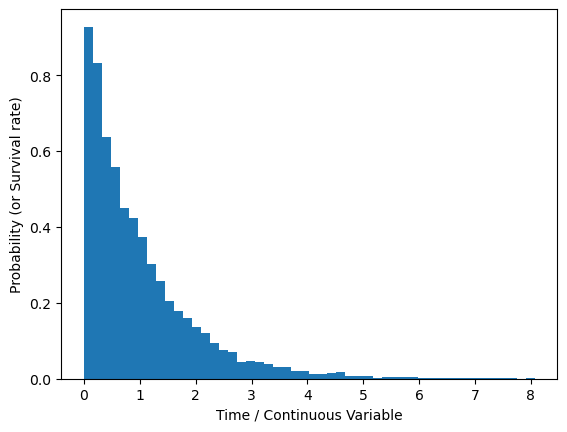

In [8]:
data = np.random.exponential(scale=1, size=10000)
plt.hist(data, bins=50, density=True)
plt.xlabel("Time / Continuous Variable")
plt.ylabel("Probability (or Survival rate)")
plt.show()

## Beta Distribution

- a = number of successes (e.g., clicks)
- b = number of failures (e.g., no clicks)
  
This graph suggests that the most likely value for the probability being modeled is around 0.2, but there's still uncertainty. The curve is skewed toward lower probabilities, meaning:
- You believe the true probability (e.g., click-through rate, conversion rate, success rate) is most likely between 0.1 and 0.3.
- Values closer to 0.5 or above are less likely, based on the current data.
- The shape reflects limited success data — for example, a few clicks out of many views.

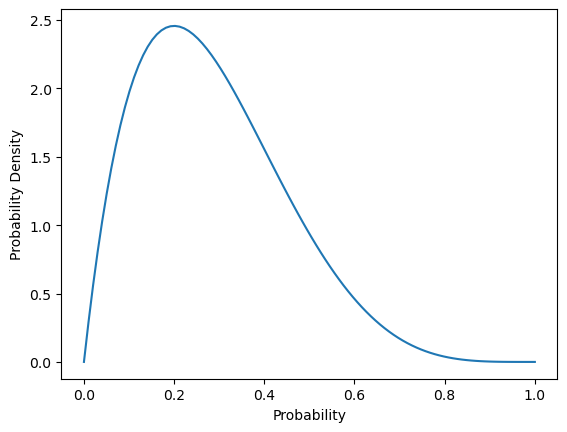

In [46]:
from scipy.stats import beta

x = np.linspace(0, 1, 100)
plt.plot(x, beta.pdf(x, a=2, b=5))
plt.xlabel("Probability")
plt.ylabel("Probability Density")
plt.show()

### Gamma Distribution

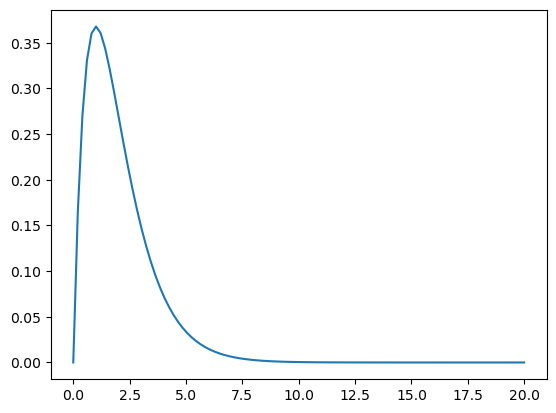

In [3]:
from scipy.stats import gamma

x = np.linspace(0, 20, 100)
plt.plot(x, gamma.pdf(x, a=2))
plt.show()